In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [73]:
df=pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [75]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [76]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [77]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [78]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [79]:
print(df[df.duplicated()])
dups=df.drop_duplicates()
print(dups)

     age   sex    bmi  children smoker     region    charges
581   19  male  30.59         0     no  northwest  1639.5631
      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1337 rows x 7 columns]


In [80]:
dups.duplicated().sum()

np.int64(0)

In [81]:
dups.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [82]:
dups.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [83]:
dups['charges'].unique()

array([16884.924 ,  1725.5523,  4449.462 , ...,  1629.8335,  2007.945 ,
       29141.3603], shape=(1337,))

In [84]:
dups.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [85]:
# let find relationship between two categories

correl=dups.select_dtypes(include=['number']).corr()

<Axes: >

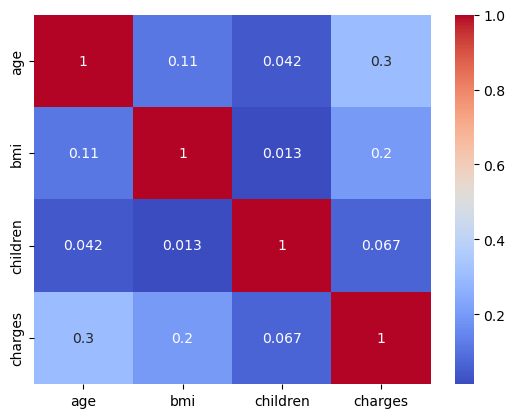

In [86]:
sns.heatmap(correl,xticklabels=correl.columns,yticklabels=correl.columns,annot=True,cmap="coolwarm")

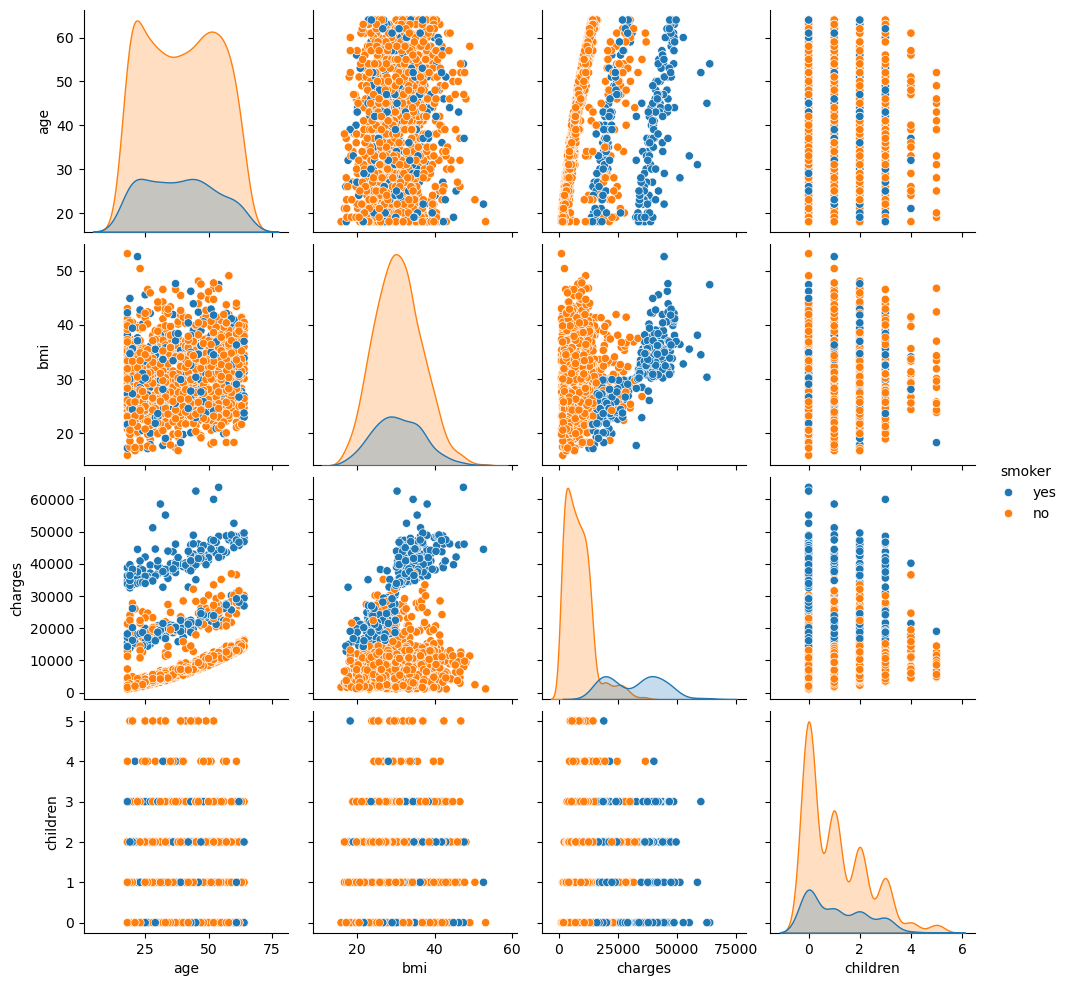

In [87]:
# sns.pairplot(dups)

sns.pairplot(
    dups,
    vars=['age','bmi','charges','children'],
    hue='smoker'
)

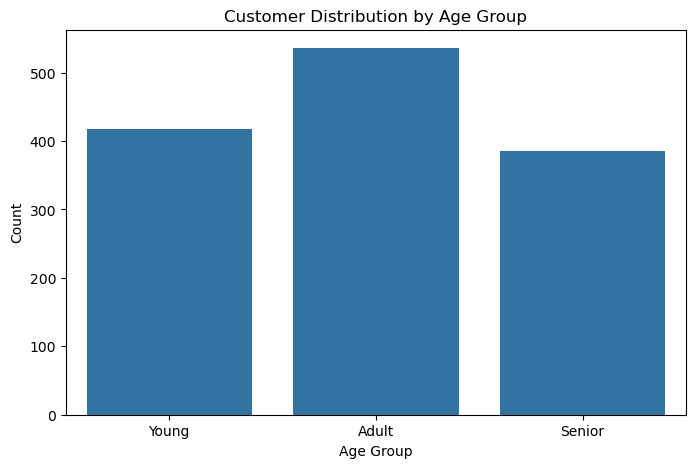

In [104]:
#create bmi category
def bmi_category(bmi):

    if bmi < 18.5:
        return "Underweight"

    elif bmi < 25:
        return "Normal"

    elif bmi < 30:
        return "Overweight"

    else:
        return "Obese"

df["BMI_Category"] = df["bmi"].apply(bmi_category)




# viz

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Age_Group",
    order=["Young", "Adult", "Senior"]
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

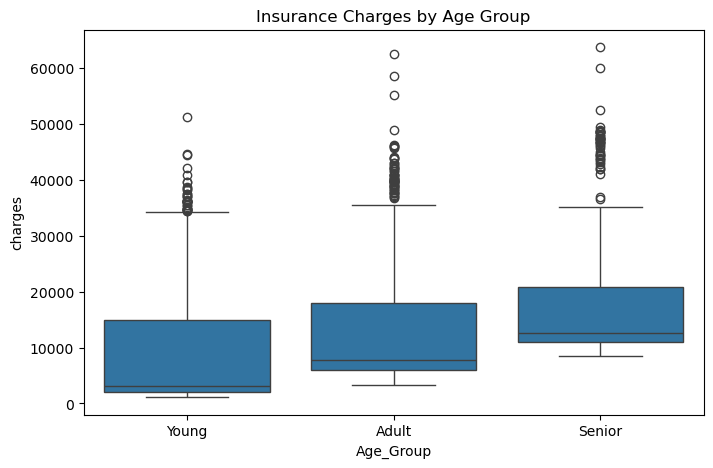

In [90]:
#create age grp
def age_group(age):

    if age < 30:
        return "Young"

    elif age < 50:
        return "Adult"

    else:
        return "Senior"

df["Age_Group"] = df["age"].apply(age_group)


# Which age group pays higher insurance charges?

plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x="Age_Group",
            y="charges")

plt.title("Insurance Charges by Age Group")
plt.show()


# Highest Median value 
# Senior citizens generally incur higher medical expenses and therefore pay higher insurance charges.

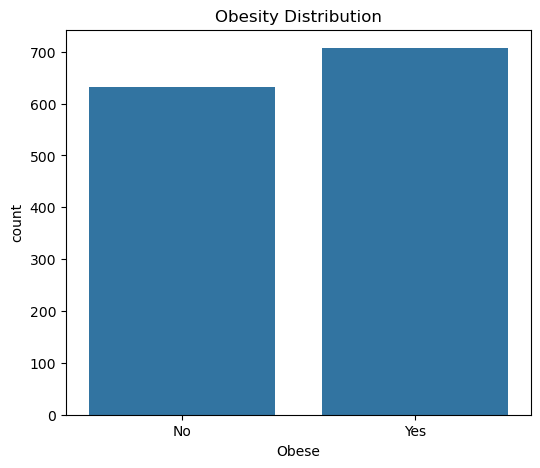

In [91]:
df["Obese"] = (df["bmi"] >= 30).astype(int)

# viz
plt.figure(figsize=(6,5))

sns.countplot(data=df,
              x="Obese")

plt.xticks([0,1],["No","Yes"])

plt.title("Obesity Distribution")
plt.show()

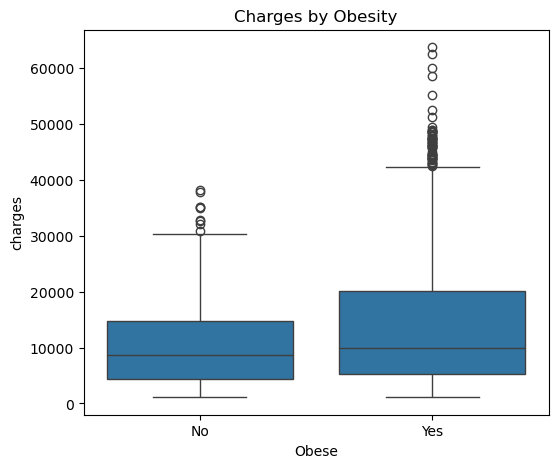

In [92]:
# medical charges for obese or non-obese customers?
plt.figure(figsize=(6,5))

sns.boxplot(data=df,
            x="Obese",
            y="charges")

plt.xticks([0,1],["No","Yes"])

plt.title("Charges by Obesity")
plt.show()

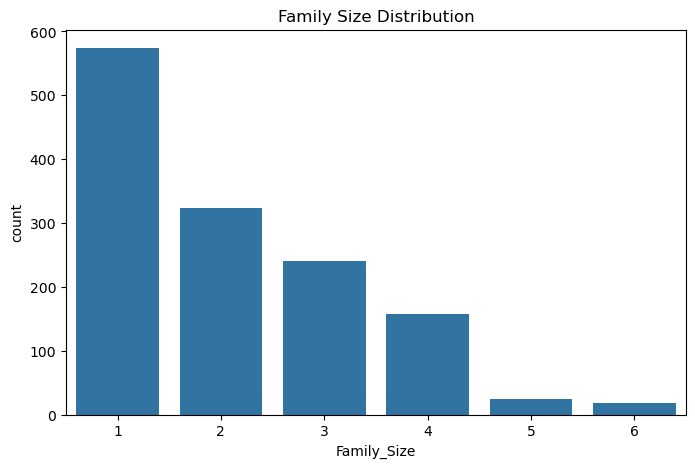

In [93]:
df["Family_Size"] = df["children"] + 1


# viz
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="Family_Size")

plt.title("Family Size Distribution")
plt.show()



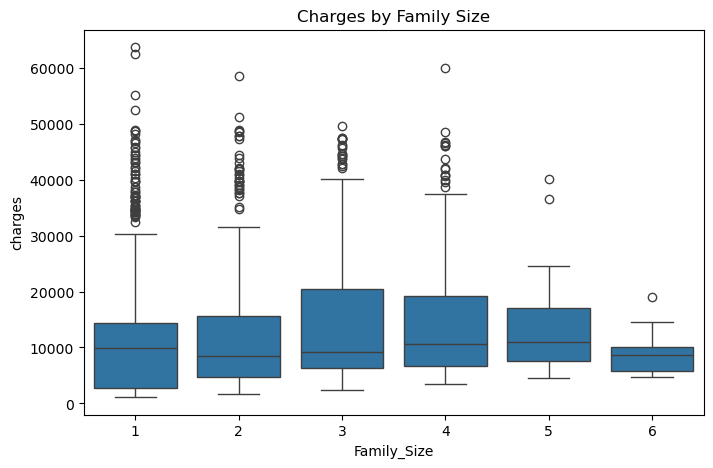

In [94]:
# do large family pays more charges?
plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x="Family_Size",
            y="charges")

plt.title("Charges by Family Size")
plt.show()

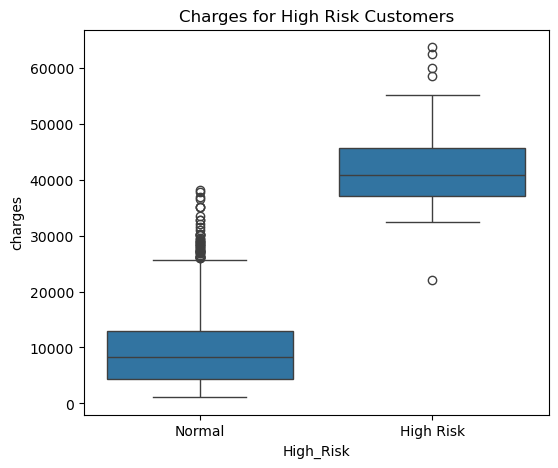

In [95]:
df["High_Risk"] = (
    (df["smoker"] == "yes") &
    (df["bmi"] >= 30)
).astype(int)

# viz

plt.figure(figsize=(6,5))

sns.boxplot(data=df,
            x="High_Risk",
            y="charges")

plt.xticks([0,1],["Normal","High Risk"])

plt.title("Charges for High Risk Customers")
plt.show()

Senior
No     1224
Yes     114
Name: count, dtype: int64


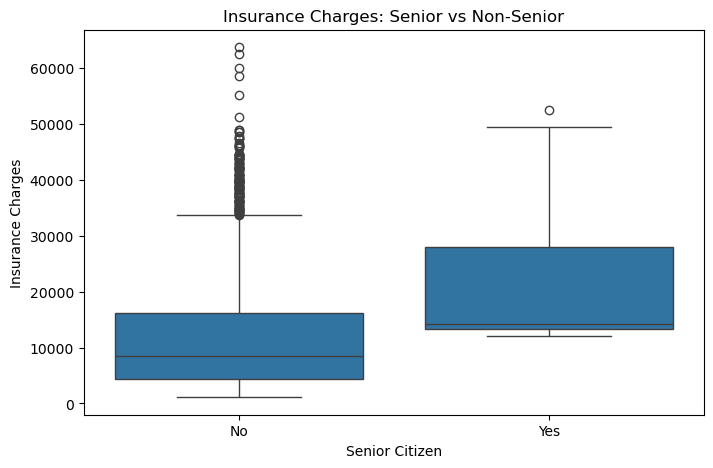

In [112]:
# charges for senior vs non-senior


df["Senior"] = df["age"].apply(lambda x: "Yes" if x >= 60 else "No")

print(df["Senior"].value_counts())

 
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Senior",
    y="charges"
)

plt.title("Insurance Charges: Senior vs Non-Senior")
plt.xlabel("Senior Citizen")
plt.ylabel("Insurance Charges")

plt.show()


# print(df.columns.tolist())

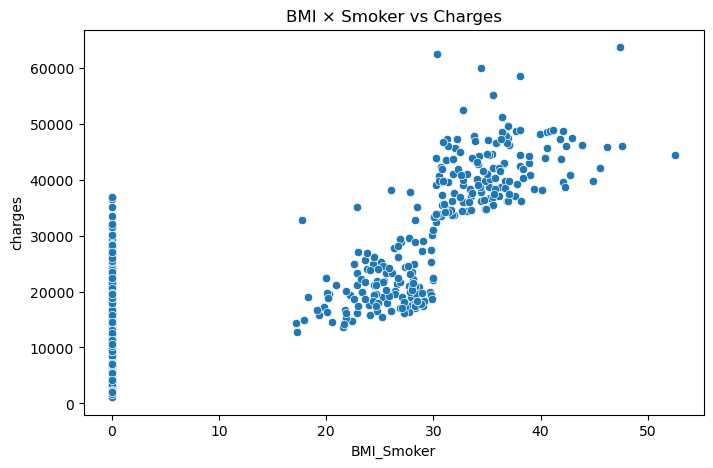

In [97]:
df["smoker"] = df["smoker"].map({
    "no": 0,
    "yes": 1
})

df["BMI_Smoker"] = df["bmi"] * df["smoker"]


plt.figure(figsize=(8,5))

sns.scatterplot(data=df,
                x="BMI_Smoker",
                y="charges")

plt.title("BMI × Smoker vs Charges")
plt.show()

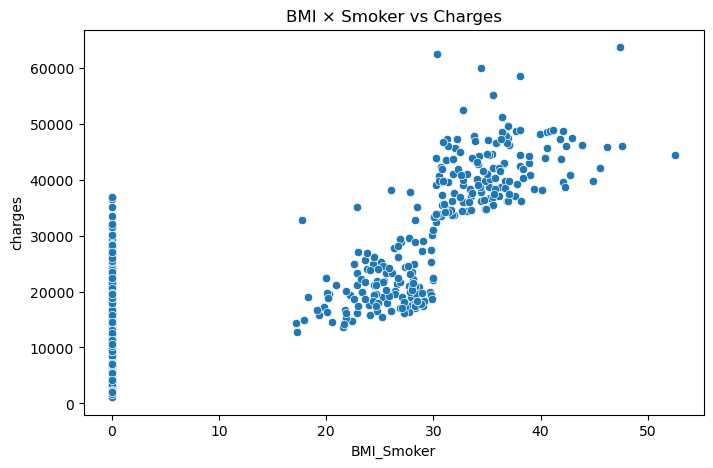

In [98]:
df["Age_BMI"] = df["age"] * df["bmi"]

plt.figure(figsize=(8,5))

sns.scatterplot(data=df,
                x="BMI_Smoker",
                y="charges")

plt.title("BMI × Smoker vs Charges")
plt.show()

In [99]:
df["Charges_Per_Child"] = df["charges"] / (df["children"] + 1)

<Axes: xlabel='charges'>

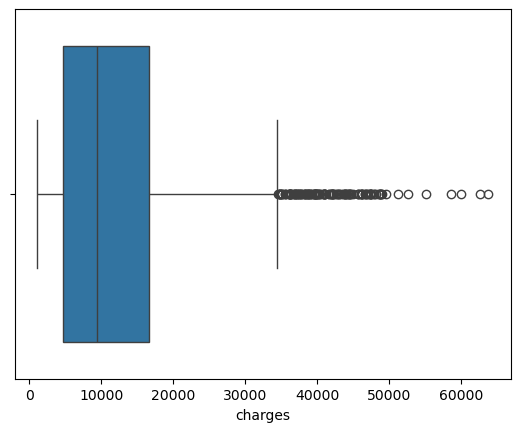

In [100]:
sns.boxplot(data=df,x="charges")

<Axes: ylabel='bmi'>

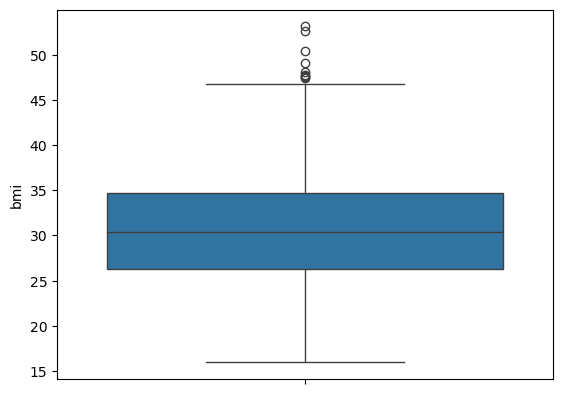

In [101]:
sns.boxplot(data=df,
            y="bmi")

EDA OPERATIONS AFTER FEATURE ENGINEERING 


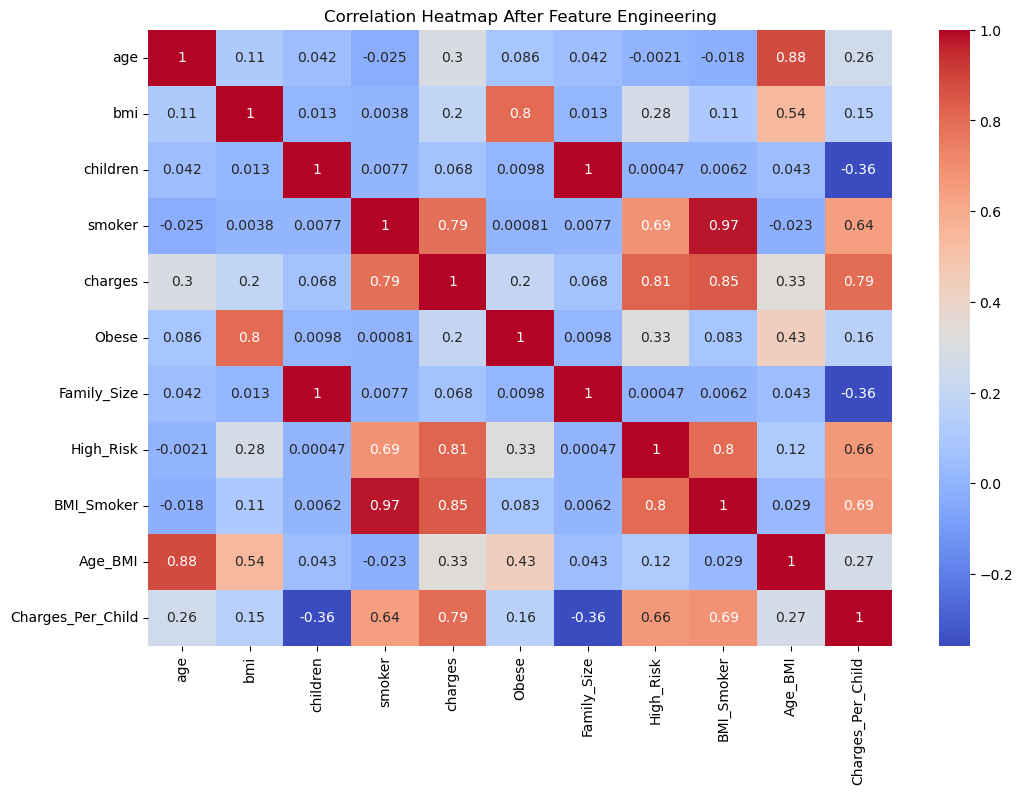

In [102]:
print("EDA OPERATIONS AFTER FEATURE ENGINEERING ")

plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap After Feature Engineering")
plt.show()

MULTI-DIMENSIONAL VISUALIZATIONS FOR INSURANCE DATA


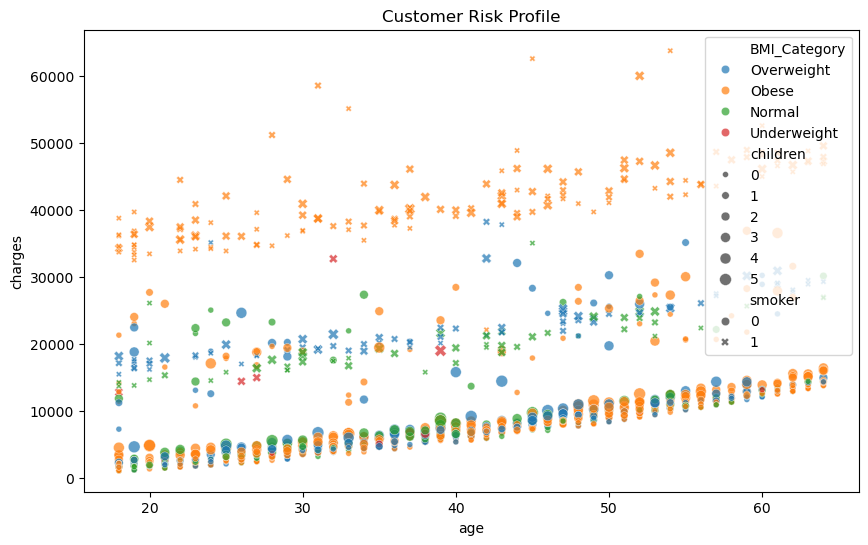

In [113]:
print("MULTI-DIMENSIONAL VISUALIZATIONS FOR INSURANCE DATA")

plt.figure(figsize=(10,6))

sns.scatterplot(data=df,
                x="age",
                y="charges",
                hue="BMI_Category",
                style="smoker",
                size="children",
                alpha=0.7)

plt.title("Customer Risk Profile")
plt.show()


# To predict high cost customers
# X-axis: Age
# Y-axis: Insurance Charges
# Color: BMI Category
# Marker Style: Smoker or Non-Smoker
# Marker Size: Number of Children

Colors distinguish smokers and non-smokers.
You can easily see that smokers generally have much higher insurance charges.


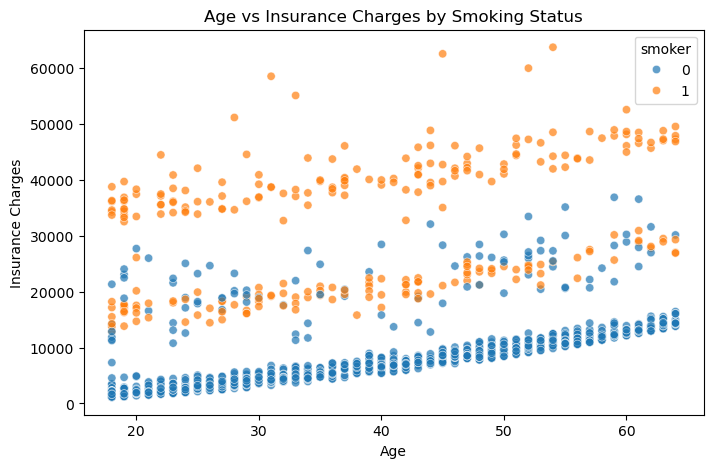

In [117]:
print("Colors distinguish smokers and non-smokers.\nYou can easily see that smokers generally have much higher insurance charges.")

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="age",
    y="charges",
    hue="smoker",
    alpha=0.7
)

plt.title("Age vs Insurance Charges by Smoking Status")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")

plt.show()

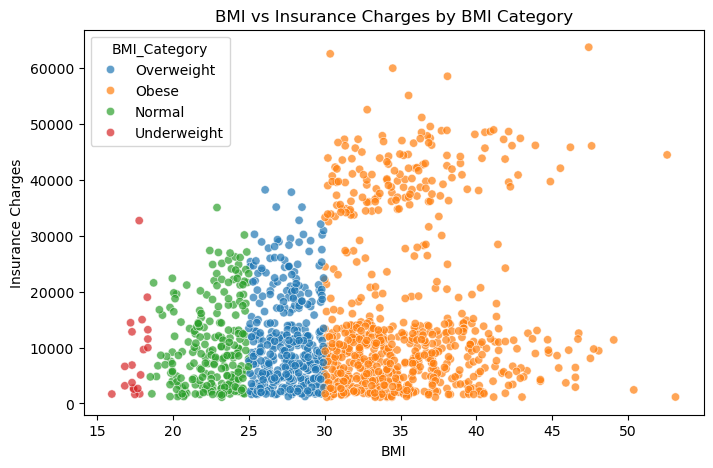

Compare insurance charges across BMI categories.


In [118]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    hue="BMI_Category",
    alpha=0.7
)

plt.title("BMI vs Insurance Charges by BMI Category")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.show()

print("Compare insurance charges across BMI categories.")

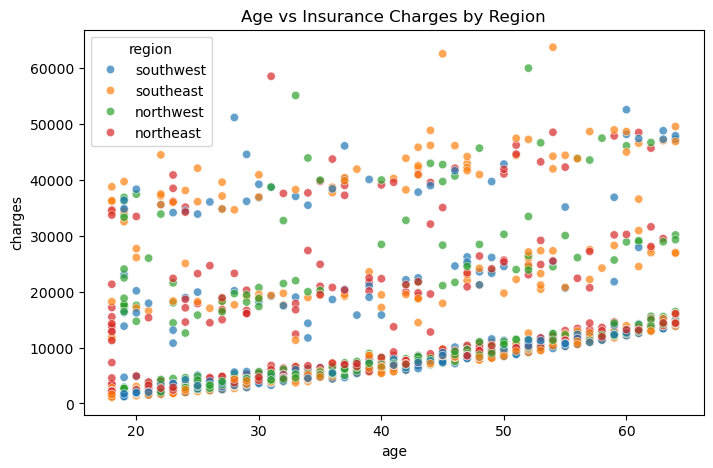

Useful for checking whether customers from different regions have noticeably different charge patterns.


In [119]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="age",
    y="charges",
    hue="region",
    alpha=0.7
)

plt.title("Age vs Insurance Charges by Region")

plt.show()
print("Useful for checking whether customers from different regions have noticeably different charge patterns.")


In [120]:
print("EDA OPERATIONS ALONG WITH SEABORN PLOTS ARE COMPLETED SUCCESSFULLY")

EDA OPERATIONS ALONG WITH SEABORN PLOTS ARE COMPLETED SUCCESSFULLY
